In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Prepare Dataset**

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vencerlanz09/taco-dataset-yolo-format")

print("Path to dataset files:", path)

100%|██████████| 232M/232M [00:08<00:00, 27.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1


In [3]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/train
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/train/labels
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/train/images
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/test
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/test/labels
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/test/images
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/valid
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/valid/labels
/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/valid/images


In [4]:
import yaml
import os

# Define the content of the data.yaml file
yaml_content = """
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 18
names: ['Aluminium foil', 'Bottle cap', 'Bottle', 'Broken glass', 'Can', 'Carton', 'Cigarette', 'Cup', 'Lid', 'Other litter', 'Other plastic', 'Paper', 'Plastic bag - wrapper', 'Plastic container', 'Pop tab', 'Straw', 'Styrofoam piece', 'Unlabeled litter']

roboflow:
  workspace: divya-lzcld
  project: taco-mqclx
  version: 3
  license: CC BY 4.0
  url: https://universe.roboflow.com/divya-lzcld/taco-mqclx/dataset/3
"""

# Define the path to save the data.yaml file
yolo_yaml_path = os.path.join("/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1", "data.yaml")

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(yolo_yaml_path), exist_ok=True)

# Write the content to the data.yaml file
with open(yolo_yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"data.yaml file created at: {yolo_yaml_path}")

data.yaml file created at: /root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/data.yaml


In [5]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 14.9 MB/s eta 0:00:00


## **Model and training**

In [6]:
from ultralytics import YOLO
import os

# Load a model
model_path = "/content/drive/MyDrive/yolov8s_trash/best10k59cls.pt"
model = YOLO("yolov8s.pt")  # load a pretrained model

# Define the correct path to the data.yaml file
yolo_yaml_path = os.path.join("/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1", "data.yaml")

# Train the model (total 70 epochs)
results = model.train(
    data=yolo_yaml_path,
    epochs=50,              # after train with 50 epochs
    imgsz=480,
    batch=48,
    optimizer="AdamW",
    lr0=5e-5,
    cache=True,
    patience=5,
    plots=True,
    model=model_path
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=48, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, 

In [8]:
import shutil
import os

source_path = '/content/runs/detect/train/weights/best.pt'
destination_path = '/content/drive/MyDrive/yolov8s_trash/best6k18cls.pt'

# Create the destination directory if it doesn't exist
os.makedirs(os.path.dirname(destination_path), exist_ok=True)

shutil.copy(source_path, destination_path)
print(f"File copied to {destination_path}")

File copied to /content/drive/MyDrive/yolov8s_trash/best6k18cls.pt


## **Evaluate**

In [9]:
model_path = '/content/drive/MyDrive/yolov8s_trash/best6k18cls.pt'
model = YOLO(model_path)
metrics = model.val()

Ultralytics 8.3.209 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,132,550 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4.8±2.3 MB/s, size: 35.6 KB)
val: Scanning /root/.cache/kagglehub/datasets/vencerlanz09/taco-dataset-yolo-format/versions/1/valid/labels.cache... 1704 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1704/1704 3.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 6.1it/s 17.5s
                   all       1704       4830      0.478       0.34      0.345      0.267
        Aluminium foil         48         62      0.524      0.452      0.465      0.371
            Bottle cap        347        459      0.542      0.664      0.662      0.518
                Bottle        275        320      0.568      0.422       0.46      0.294
          Broken glass         13        123      0.247     0.0244     0

In [12]:
# Show val detect
import matplotlib.pyplot as plt

# Labels
print("Labels:")
img = plt.imread("/content/runs/detect/val/val_batch0_labels.jpg")
plt.figure(figsize=(18, 18))
plt.imshow(img)
plt.axis('off')
plt.show()

# Pred
print("\nPred:")
img = plt.imread("/content/runs/detect/val/val_batch0_pred.jpg")
plt.figure(figsize=(18, 18))
plt.imshow(img)
plt.axis('off')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## **Show result**


image 1/1 /content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic.webp: 384x480 2 Plastic bag - wrappers, 1 Plastic container, 10.6ms
Speed: 10.5ms preprocess, 10.6ms inference, 16.9ms postprocess per image at shape (1, 3, 384, 480)


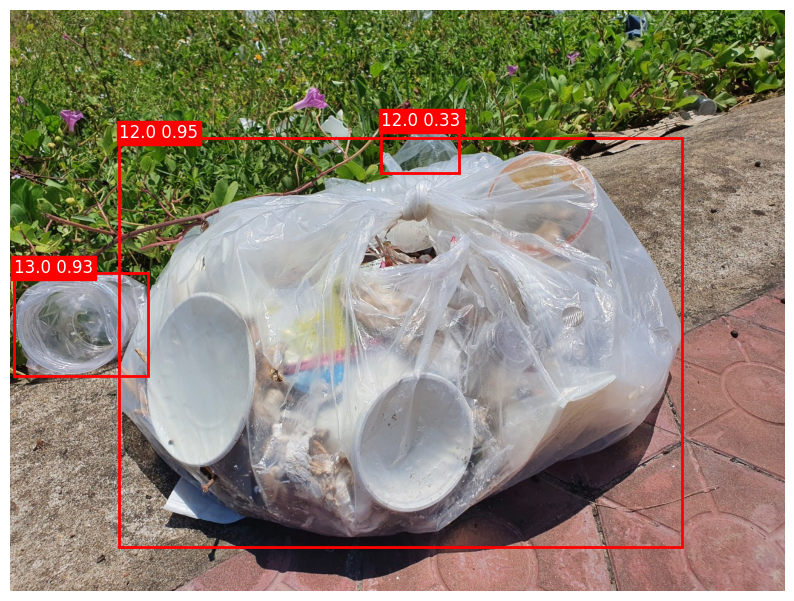

In [ ]:
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt

input_image_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic.webp"
image = Image.open(input_image_path)

train_model_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/best6kcontinute.pt"

model = YOLO(train_model_path)
results = model.predict(source=input_image_path)

# Plot the image and draw the bounding boxes
plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

# Extract predictions
for result in results:
    # Extract bounding box coordinates
    boxes = result.boxes.xyxy.cpu().numpy()

    # Extract confidence scores
    scores = result.boxes.conf.cpu().numpy()

    # Extract class labels
    labels = result.boxes.cls.cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1

        # Draw the bounding box
        rect = plt.Rectangle((x1, y1), width, height, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(rect)

        # Draw the label and confidence
        plt.text(x1, y1, f'{label} {score:.2f}', color='white', fontsize=12, bbox=dict(facecolor='red', edgecolor='red', pad=2.0))

plt.axis('off')
plt.show()



image 1/1 /content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic3.jpg: 384x480 3 Bottle caps, 10.7ms
Speed: 1.8ms preprocess, 10.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 480)


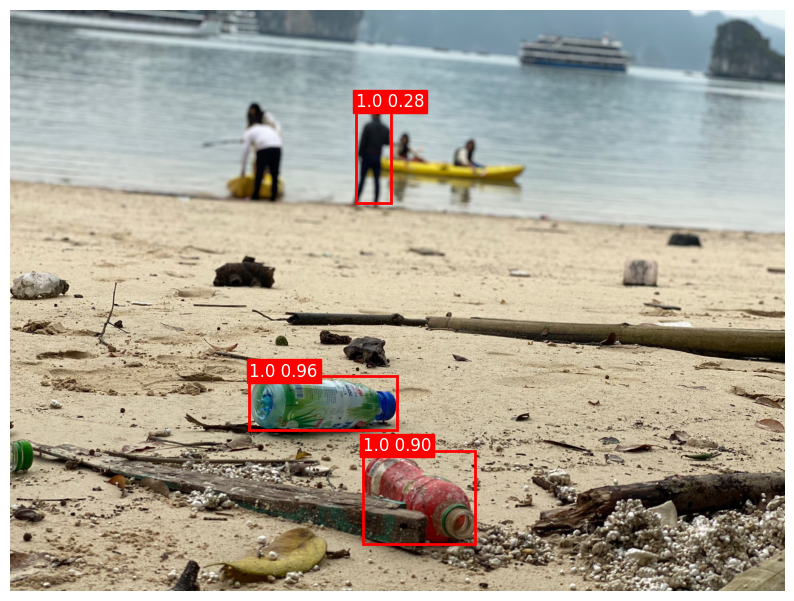

In [ ]:
from PIL import Image
from ultralytics import YOLO
import matplotlib.pyplot as plt

input_image_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/plastic3.jpg"
image = Image.open(input_image_path)

train_model_path = "/content/drive/MyDrive/Trash-paper-plastic-glass-CLS/best6kcontinute.pt"

model = YOLO(train_model_path)
results = model.predict(source=input_image_path)

# Plot the image and draw the bounding boxes
plt.figure(figsize=(10, 10))
plt.imshow(image)
ax = plt.gca()

# Extract predictions
for result in results:
    # Extract bounding box coordinates
    boxes = result.boxes.xyxy.cpu().numpy()

    # Extract confidence scores
    scores = result.boxes.conf.cpu().numpy()

    # Extract class labels
    labels = result.boxes.cls.cpu().numpy()

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        width, height = x2 - x1, y2 - y1

        # Draw the bounding box
        rect = plt.Rectangle((x1, y1), width, height, edgecolor='red', facecolor='none', linewidth=2)
        ax.add_patch(rect)

        # Draw the label and confidence
        plt.text(x1, y1, f'{label} {score:.2f}', color='white', fontsize=12, bbox=dict(facecolor='red', edgecolor='red', pad=2.0))

plt.axis('off')
plt.show()
